# NB05 — Feature Engineering

**Project**: `genotype_to_phenotype_enigma`  
**Depends on**: NB01-NB04 outputs, genome depot

## Goal

Construct the modeling matrices at four feature levels for variance partitioning (NB06) and GBDT modeling (NB07). Each level adds progressively more specific genomic information.

## Feature levels

| Level | Features | Dim | What it captures |
|---|---|---|---|
| **L0 — Phylogeny** | GTDB order (one-hot) + metabolic guild (one-hot) | 28 | "What kind of organism is this?" |
| **L1 — Bulk scalars** | Genome size, gene count, contigs, unique KOs, coding density, operons, rRNA/tRNA copies | 8 | "How big/complex is the genome?" |
| **L2 — Specific features** | Top-100 KO presence/absence + 23 COG class counts | 123 | "Which specific genes/pathways does it have?" |
| **L3 — Condition** | Condition class (carbon/amino acid/metal/antibiotic/nitrogen/nucleoside/other) + log(concentration) | 7 | "What substrate/stress is being tested?" |

Total: **166 features** (plus strain/condition IDs and 5 target columns).

## Modeling table

486 (strain x condition) anchor pairs, each with:
- 5 targets: `growth_binary`, `mu_max`, `max_A`, `lag`, `auc`
- 166 features across 4 levels
- 7 leave-one-strain-out CV folds (4 Pseudomonas_E, 1 Cupriavidus, 1 Acidovorax, 1 Pedobacter)


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image

DATA = Path('../data')
FIG = Path('../figures')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)


## 1. Feature level summary

In [2]:
mt = pd.read_parquet(DATA / 'modeling' / 'anchor_modeling_table.parquet')
print(f'Modeling table: {mt.shape[0]} rows × {mt.shape[1]} columns')
print(f'\nTargets:')
print(f'  growth_binary: {mt.growth_binary.sum()}/{len(mt)} growth ({100*mt.growth_binary.mean():.1f}%)')
print(f'  mu_max: {mt.mu_max.notna().sum()} non-null (median {mt.mu_max.median():.4f} h⁻¹)')
print(f'  lag: {mt.lag.notna().sum()} non-null (median {mt.lag.median():.1f} h)')
print(f'  max_A: {mt.max_A.notna().sum()} non-null (median {mt.max_A.median():.3f} OD)')
print(f'\nFeature counts:')
for prefix, label in [('L0_', 'L0 Phylogeny'), ('L1_', 'L1 Scalars'), ('L2_', 'L2 KO+COG'), ('L3_', 'L3 Condition')]:
    n = sum(1 for c in mt.columns if c.startswith(prefix))
    print(f'  {label}: {n}')


Modeling table: 486 rows × 4378 columns

Targets:
  growth_binary: 275/486 growth (56.6%)
  mu_max: 275 non-null (median 0.0267 h⁻¹)
  lag: 275 non-null (median 13.0 h)
  max_A: 275 non-null (median 0.266 OD)

Feature counts:
  L0 Phylogeny: 28
  L1 Scalars: 8
  L2 KO+COG: 4328
  L3 Condition: 7


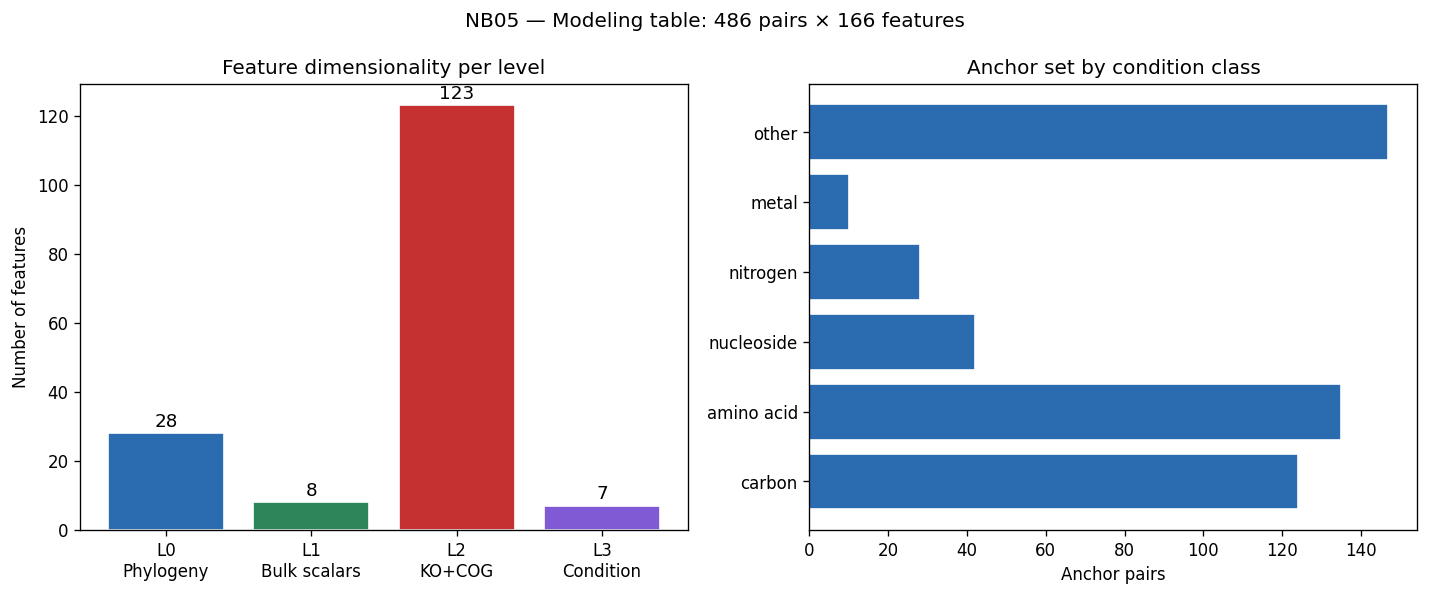

In [3]:
Image(filename=str(FIG / 'NB05_feature_summary.png'))

## 2. Target distributions

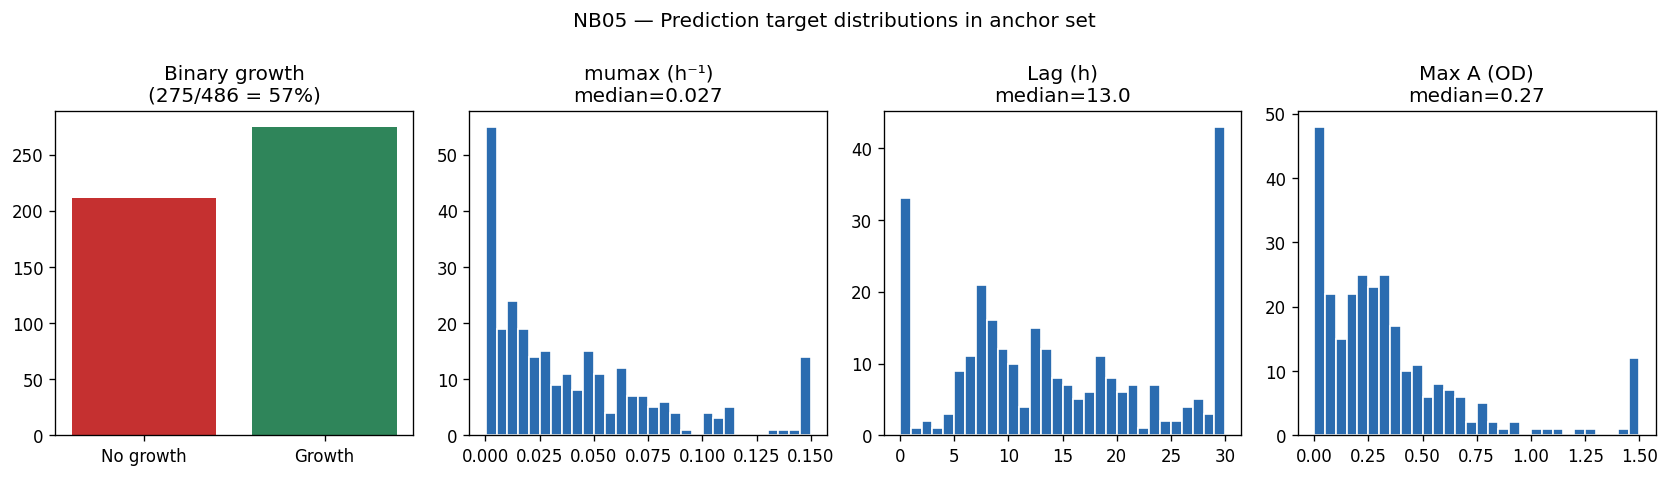

In [4]:
Image(filename=str(FIG / 'NB05_target_distributions.png'))

## 3. CV fold structure

In [5]:
cv = pd.read_csv(DATA / 'modeling' / 'cv_folds.tsv', sep='\t')
print('Leave-one-strain-out CV folds:')
for _, r in cv.iterrows():
    n = len(mt[mt.strain == r.strain])
    n_pos = mt[mt.strain == r.strain].growth_binary.sum()
    print(f'  Fold {r.strain} ({r.genus}): {n} pairs, {n_pos} growth-positive')


Leave-one-strain-out CV folds:
  Fold FW300-N1B4 (Pseudomonas_E): 72 pairs, 47 growth-positive
  Fold FW300-N2E2 (Pseudomonas_E): 72 pairs, 40 growth-positive
  Fold FW300-N2E3 (Pseudomonas_E): 72 pairs, 44 growth-positive
  Fold FW507-4G11 (Cupriavidus): 64 pairs, 43 growth-positive
  Fold GW101-3H11 (Acidovorax): 64 pairs, 22 growth-positive
  Fold GW456-L13 (Pseudomonas_E): 72 pairs, 46 growth-positive
  Fold GW460-11-11-14-LB5 (Pedobacter): 70 pairs, 33 growth-positive


## 4. Feature-level files on disk

In [6]:
import os
for f in sorted(os.listdir(DATA / 'features')):
    size = os.path.getsize(DATA / 'features' / f)
    print(f'  {f}: {size:,} bytes')
print()
for f in sorted(os.listdir(DATA / 'modeling')):
    size = os.path.getsize(DATA / 'modeling' / f)
    print(f'  {f}: {size:,} bytes')


  L0_phylogeny.parquet: 17,584 bytes
  L1_scalars.parquet: 12,030 bytes
  L2_cog_counts.parquet: 24,055 bytes
  L2_ko_binary.parquet: 3,989,775 bytes
  L2_ko_pca50.parquet: 85,464 bytes
  L2_ko_prevalence_filtered.parquet: 2,411,961 bytes
  L3_condition.parquet: 5,991 bytes

  anchor_gbdt_table.parquet: 2,498,388 bytes
  anchor_linear_table.parquet: 89,460 bytes
  anchor_modeling_table.parquet: 2,498,388 bytes
  cv_folds.tsv: 187 bytes


## 5. What this enables

**NB06 (variance partitioning)**: Fit nested models M0 (L0 only) → M1 (L0+L1) → M2 (L0+L1+L2) → M3 (L0+L1+L2+L3). Report incremental R² at each level to determine how much growth variance is attributable to phylogeny, bulk genome properties, specific genes, and condition identity.

**NB07 (GBDT modeling)**: Train LightGBM on the full 166-feature matrix with leave-one-strain-out CV. Compare to GapMind baseline (L2 pathway-level) and taxonomy-only baseline (L0).

**NB08 (FB concordance)**: Map top-SHAP KO features back to FB fitness loci via `fb_pangenome_link.tsv` to validate biological meaningfulness.

## Limitations

- **Top-100 KOs only**: The full 7,167-KO matrix was reduced to the top 100 by variance for the anchor set. This may miss strain-specific KOs important for rare conditions. NB07 can test full KO matrix on a per-strain basis.
- **Missing features**: GC%, codon usage bias (CUB/gRodon), and molecular fingerprints (Morgan FP) are not yet computed. GC% requires genome sequences; CUB requires coding sequences; Morgan FP requires RDKit. These can be added in a follow-up pass.
- **rRNA/tRNA sparse**: Only 43/123 strains have rRNA/tRNA gene counts from the depot; median-imputed for the rest.
- **No interaction terms yet**: L2×L3 interaction features (e.g., metal resistance KO × metal condition) are planned but not in this initial matrix. Add if L2 and L3 show independent signal in NB06.
